[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danieldidriksen/Bachelor_Project/blob/main/NYC_Orientation_Analysis.ipynb)

## Importing the Library

In [30]:
try:
    from Image_analysis_class import ImageAnalyzer as IA

except ModuleNotFoundError:
    !git clone https://github.com/danieldidriksen/Bachelor_Project.git
    from Bachelor_Project.Image_analysis_class import ImageAnalyzer as IA

## Importing your image, converting it to grayscale and printing it

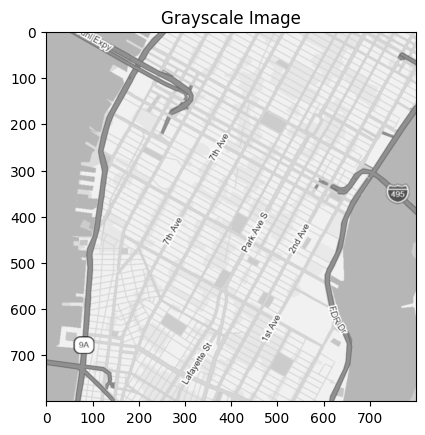

In [31]:
imagefile = r'Images\NYC.webp'


img = IA.load_grayscale(imagefile)[200:1000,300:1100]

IA.plot_image(img)

## Chose your $\sigma$ values, and compute structure tensor values

In [32]:
sigma_derivative = 1
sigma_tensor = 2

## create your structure tensor, find its eigen values and vectors, and find the angle of dominant orientation for each structure tensor 

In [33]:
# S = ImageAnalyzer.tensor_to_matrix(S11, S12, S22)

S = IA.compute_structure_tensor(img, sigma_derivative, sigma_tensor)
evals, evecs = IA.eigendecomposition(S)

lam_s, lam_l, v_s, v_l = IA.split_eigenpairs(evals, evecs)

theta = IA.orientation_from_eigenvectors(v_s)

##  Orientation vectors

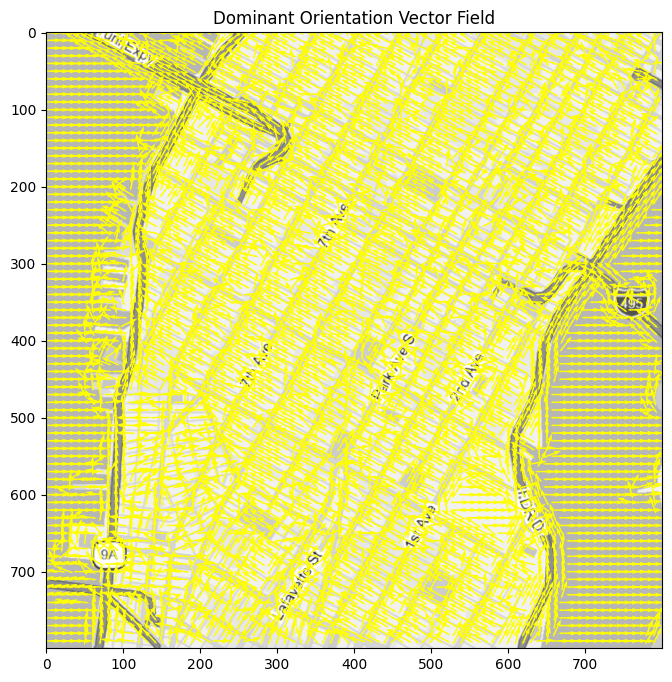

In [34]:
IA.plot_orientation_vectors(img, S, step = 10, scale = 40)

## chose energy cutoff, compute energy, isotropy, anisotropy, create an energy mask and apply the mask 

In [35]:
percent = 45

aniso_masked = IA.compute_anisotropy_masked(S)

## Visualize dominant orientatioin on orignal picture with defined energy cutoff

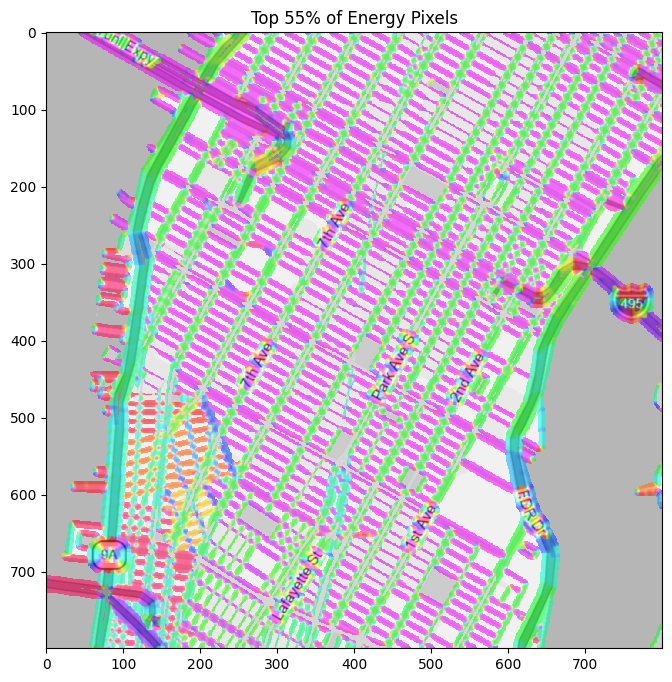

In [36]:
IA.plot_orientation_overlay(
    img,
    theta,
    aniso_masked,
    percent
)

## computing values counts and bins for histogram

In [37]:
counts, centers, width = IA.compute_orientation_histogram(
    theta,
    aniso_masked,
    bins=180
)


## Plotting the orientational Histogram 

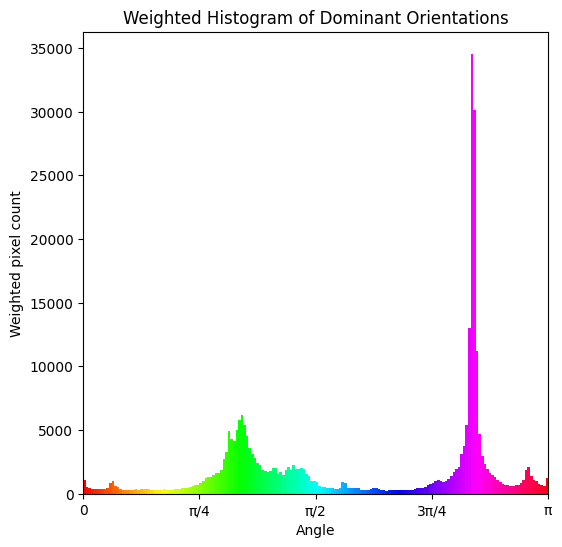

In [38]:

IA.plot_orientation_histogram(counts, centers, width, weighted = True)

## Plot Polar Histogram

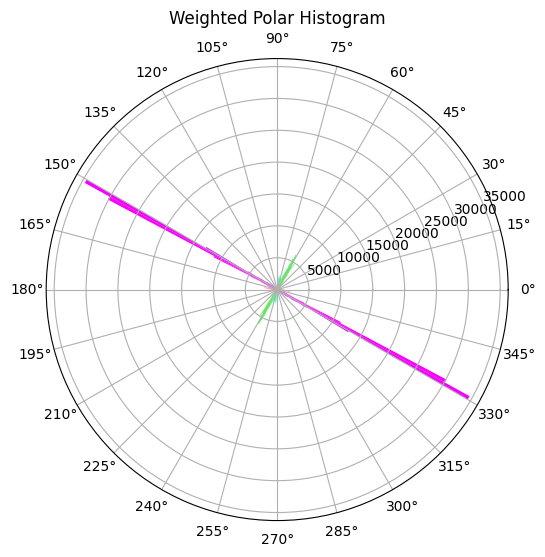

In [39]:
IA.plot_polar_histogram(
    counts, centers, width, weighted= True
)

## Chose Dominant orientations, and compute the binned angles to include

In [40]:
# Define dominant orientations and tolerance 
centers = [55, 145]
tolerance_deg= 10

chosen_theta = IA.bin_orientations(theta, centers, tolerance_deg)

## Plot grouped Dominant Orientations

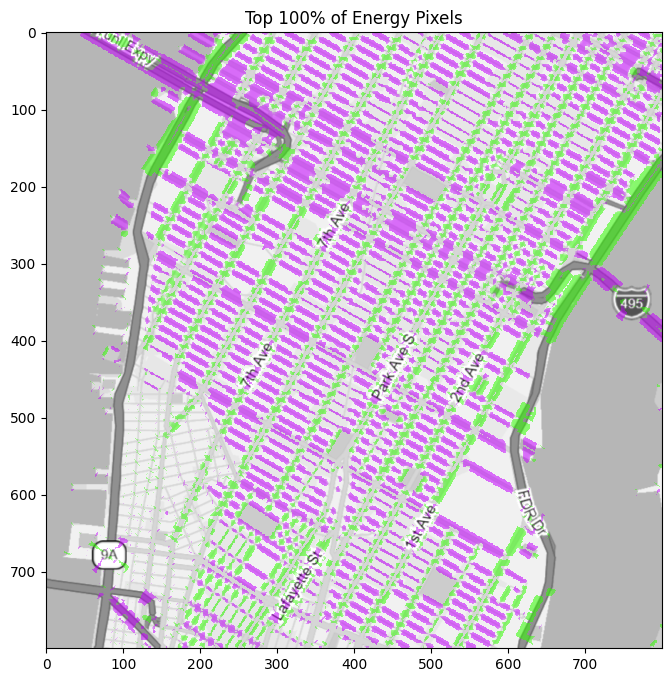

In [41]:
IA.plot_orientation_overlay(img, chosen_theta, aniso_masked)

## computing Orientationally grouped Histogram

In [42]:
grouped_counts, grouped_bin_centers, grouped_bin_width = IA.compute_orientation_histogram(chosen_theta, aniso_masked)

## Plotting Orientationally grouped Histogram

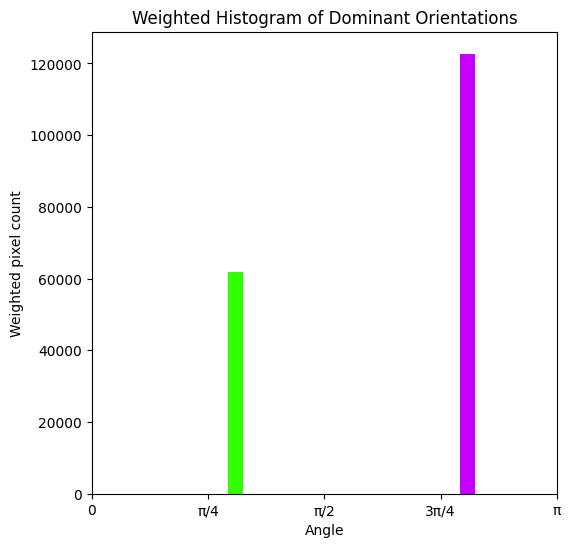

In [43]:
IA.plot_orientation_histogram(grouped_counts, grouped_bin_centers, 0.1, weighted = True)

## Plotting Orientationally grouped Polar Histogram

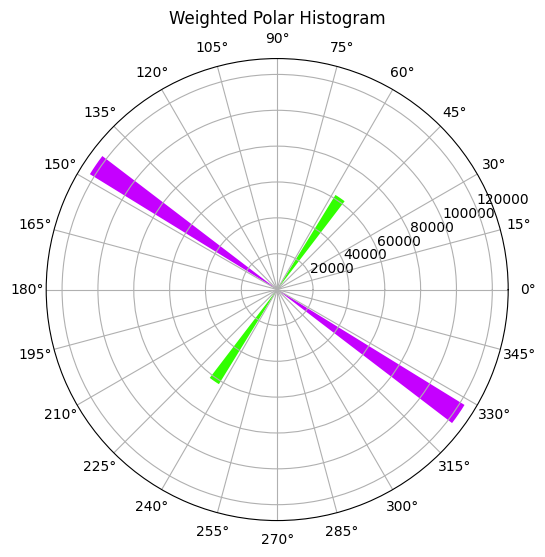

In [44]:
IA.plot_polar_histogram(grouped_counts, grouped_bin_centers, 0.1, weighted = True)

## Calculating a Organic pertentile

In [45]:
percentile = IA.compute_alignment_percentage(
    theta,
    aniso_masked,
    centers,
    tolerance_deg=10
)

## Printing Organic percentile/score

61.69% of orientations align with [55, 145]° (±10°)
which give the city an organic score of 38.31


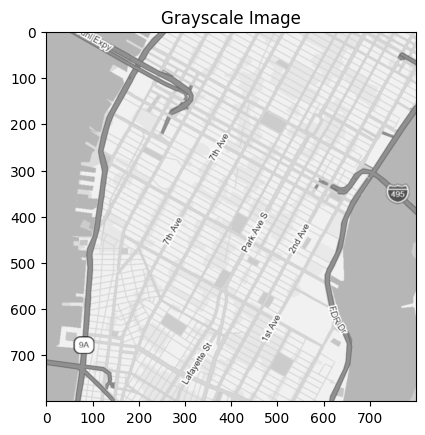

In [46]:
IA.print_alignment_percentage(
    percentile,
    centers,
    tolerance_deg
)

print(f"which give the city an organic score of {100 - percentile:.2f}")

IA.plot_image(img)